##### Copyright 2019 The TensorFlow Authors.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# TensorFlow 2 quickstart for beginners

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/quickstart/beginner"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/quickstart/beginner.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

This short introduction uses [Keras](https://www.tensorflow.org/guide/keras/overview) to:

1. Build a neural network that classifies images.
2. Train this neural network.
3. And, finally, evaluate the accuracy of the model.

This is a [Google Colaboratory](https://colab.research.google.com/notebooks/welcome.ipynb) notebook file. Python programs are run directly in the browser—a great way to learn and use TensorFlow. To follow this tutorial, run the notebook in Google Colab by clicking the button at the top of this page.

1. In Colab, connect to a Python runtime: At the top-right of the menu bar, select *CONNECT*.
2. Run all the notebook code cells: Select *Runtime* > *Run all*.

Download and install TensorFlow 2. Import TensorFlow into your program:

Note: Upgrade `pip` to install the TensorFlow 2 package. See the [install guide](https://www.tensorflow.org/install) for details.

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import math

Load and prepare the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). Convert the samples from integers to floating-point numbers:

None
(60000, 28, 28)
(60000,)


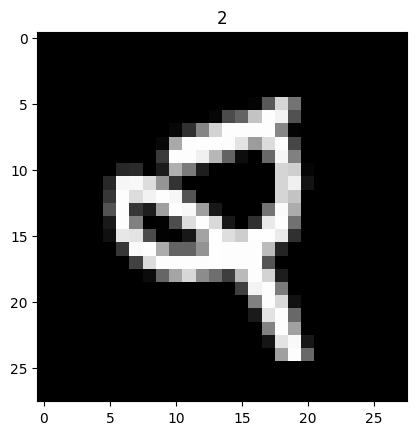

In [10]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


def show_image_and_label(index: int = np.random.randint(0, len(x_train) - 1)):
    plt.title(y_train[index])
    plt.imshow(x_train[index],cmap="gray" )
    
    
print(show_image_and_label())
print(x_train.shape)
print(y_train.shape)


Build the `tf.keras.Sequential` model by stacking layers. Choose an optimizer and loss function for training:

In [7]:
def create_model(show_summary=True, init_weights_path=None):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        # tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10)
    ])
    if show_summary:
        model.summary()

    # training
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer='adam',
                  loss=loss_fn,
                  metrics=['accuracy'])
    if init_weights_path is not None:
        model.load_weights(init_weights_path)
    return model

def create_model_2(show_summary=True, init_weights_path=None):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(10)
    ])
    if show_summary:
        model.summary()

    # training
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer='adam',
                  loss=loss_fn,
                  metrics=['accuracy'])
    if init_weights_path is not None:
        model.load_weights(init_weights_path)
    return model

def create_model_3(show_summary=True, init_weights_path=None):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(10)
    ])
    if show_summary:
        model.summary()

    # training
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    model.compile(optimizer='adam',
                  loss=loss_fn,
                  metrics=['accuracy'])
    if init_weights_path is not None:
        model.load_weights(init_weights_path)
    return model

For each example the model returns a vector of "[logits](https://developers.google.com/machine-learning/glossary#logits)" or "[log-odds](https://developers.google.com/machine-learning/glossary#log-odds)" scores, one for each class.

In [5]:
predictions = model2(x_train[:1]).numpy()
predictions

NameError: name 'model2' is not defined

The `tf.nn.softmax` function converts these logits to "probabilities" for each class: 

In [ ]:
tf.nn.softmax(predictions).numpy()

Note: It is possible to bake this `tf.nn.softmax` in as the activation function for the last layer of the network. While this can make the model output more directly interpretable, this approach is discouraged as it's impossible to
provide an exact and numerically stable loss calculation for all models when using a softmax output. 

The `losses.SparseCategoricalCrossentropy` loss takes a vector of logits and a `True` index and returns a scalar loss for each example.

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

This loss is equal to the negative log probability of the true class:
It is zero if the model is sure of the correct class.

This untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to `-tf.log(1/10) ~= 2.3`.

In [ ]:
loss_fn(y_train[:1], predictions).numpy()

In [8]:
model = create_model()
model2 = create_model_2()

model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

model2.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1742918154.812301      27 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

NameError: name 'loss_fn' is not defined

The `Model.fit` method adjusts the model parameters to minimize the loss: 

In [9]:
history = None
history = model.fit(x_train, y_train, epochs=10, validation_split=0.25)

history2 = model2.fit(x_train, y_train, epochs=10, validation_split=0.25)

model.save('./model.keras')
model2.save('./model2.keras')

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8567 - loss: 0.5014 - val_accuracy: 0.9512 - val_loss: 0.1715
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9600 - loss: 0.1370 - val_accuracy: 0.9631 - val_loss: 0.1263
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9749 - loss: 0.0891 - val_accuracy: 0.9682 - val_loss: 0.1083
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9807 - loss: 0.0642 - val_accuracy: 0.9704 - val_loss: 0.1011
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0481 - val_accuracy: 0.9715 - val_loss: 0.0954
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9896 - loss: 0.0353 - val_accuracy: 0.9729 - val_loss: 0.0947
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9912 - loss: 0.0298 - val_accuracy: 0.9719 - val_loss: 0.0994
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9941 - loss: 0.0216 - 

313/313 - 1s - 2ms/step - accuracy: 0.9763 - loss: 0.0864
{'accuracy': [0.9152666926383972, 0.9620888829231262, 0.9743333458900452, 0.980400025844574, 0.9846888780593872, 0.9879999756813049, 0.9905555844306946, 0.9934444427490234, 0.9941111207008362, 0.9956222176551819], 'loss': [0.295716792345047, 0.1294810175895691, 0.08843323588371277, 0.06459812074899673, 0.05018094554543495, 0.039080020040273666, 0.030650794506072998, 0.023179544135928154, 0.019639452919363976, 0.015165982767939568], 'val_accuracy': [0.951200008392334, 0.9630666375160217, 0.9682000279426575, 0.9703999757766724, 0.9714666604995728, 0.9728666543960571, 0.9718666672706604, 0.972599983215332, 0.9733333587646484, 0.9733999967575073], 'val_loss': [0.1715029776096344, 0.12631672620773315, 0.1082613542675972, 0.10109665989875793, 0.09536895900964737, 0.09470031410455704, 0.09940994530916214, 0.09974107146263123, 0.10222499072551727, 0.09859561175107956]}


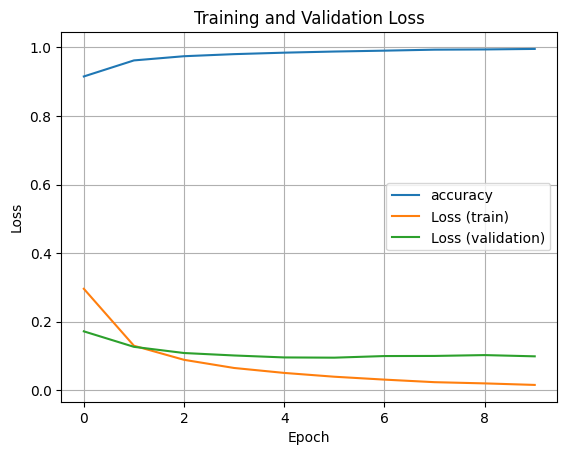

In [10]:
model.evaluate(x_test,  y_test, verbose=2)
print(history.history)
plt.plot(history.history['accuracy'], label='accuracy')

plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 - 1s - 3ms/step - accuracy: 0.9815 - loss: 0.0958
{'accuracy': [0.93586665391922, 0.9740222096443176, 0.9814888834953308, 0.986466646194458, 0.9893110990524292, 0.9909111261367798, 0.9930889010429382, 0.9933555722236633, 0.9931333065032959, 0.9944666624069214], 'loss': [0.20874592661857605, 0.08520782738924026, 0.057676609605550766, 0.041830021888017654, 0.03297837823629379, 0.02809242345392704, 0.022706156596541405, 0.019835829734802246, 0.021331442520022392, 0.016719793900847435], 'val_accuracy': [0.9614666700363159, 0.968666672706604, 0.9695333242416382, 0.9718666672706604, 0.9683333039283752, 0.9675999879837036, 0.9753999710083008, 0.9764666557312012, 0.9769333600997925, 0.9771333336830139], 'val_loss': [0.129055455327034, 0.10074705630540848, 0.10354140400886536, 0.10012012720108032, 0.12815994024276733, 0.14176435768604279, 0.10767286270856857, 0.11180716007947922, 0.11028138548135757, 0.11717217415571213]}


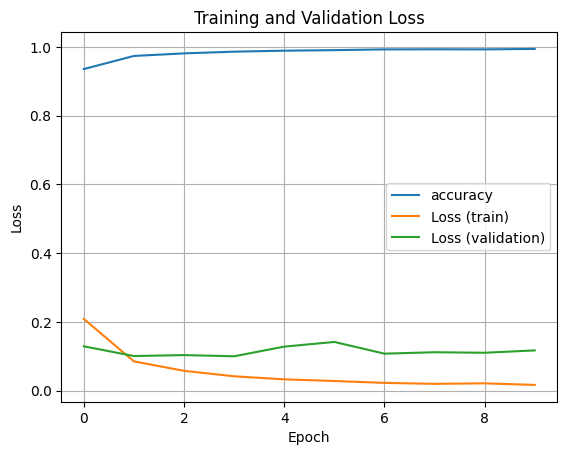

In [11]:
model2.evaluate(x_test,  y_test, verbose=2)
print(history2.history)
plt.plot(history2.history['accuracy'], label='accuracy')

plt.plot(history2.history['loss'], label='Loss (train)')
plt.plot(history2.history['val_loss'], label='Loss (validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

The `Model.evaluate` method checks the models performance, usually on a "[Validation-set](https://developers.google.com/machine-learning/glossary#validation-set)" or "[Test-set](https://developers.google.com/machine-learning/glossary#test-set)".

In [ ]:
model.evaluate(x_test,  y_test, verbose=2)

The image classifier is now trained to ~98% accuracy on this dataset. To learn more, read the [TensorFlow tutorials](https://www.tensorflow.org/tutorials/).

If you want your model to return a probability, you can wrap the trained model, and attach the softmax to it:

In [19]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [20]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[1.87911439e-07, 1.11673382e-09, 3.91649131e-08, 9.77917691e-04,
        2.30845724e-13, 2.34540565e-09, 3.61909044e-11, 9.98982131e-01,
        1.02486156e-05, 2.94105757e-05],
       [7.26088460e-13, 5.13112991e-06, 9.99994874e-01, 9.39794215e-11,
        1.92740527e-18, 1.59501774e-12, 1.93891517e-12, 3.22229217e-21,
        3.88290067e-09, 5.33927261e-15],
       [1.78802786e-08, 9.99450505e-01, 2.24363088e-04, 8.34668299e-07,
        2.93615585e-06, 5.52603261e-08, 3.70412363e-06, 3.32807940e-05,
        2.84364418e-04, 8.81793554e-08],
       [9.99979019e-01, 2.26215153e-08, 1.67919524e-07, 3.14056364e-10,
        1.18974697e-07, 1.61925351e-09, 2.07098801e-05, 2.04323154e-08,
        6.66676644e-11, 1.73170154e-08],
       [7.81074405e-09, 1.07902667e-13, 2.99488234e-09, 2.36937952e-11,
        9.99600470e-01, 9.32454253e-11, 1.57519850e-07, 1.40346651e-06,
        2.59186574e-08, 3.98017233e-04]], dtype=float32)>

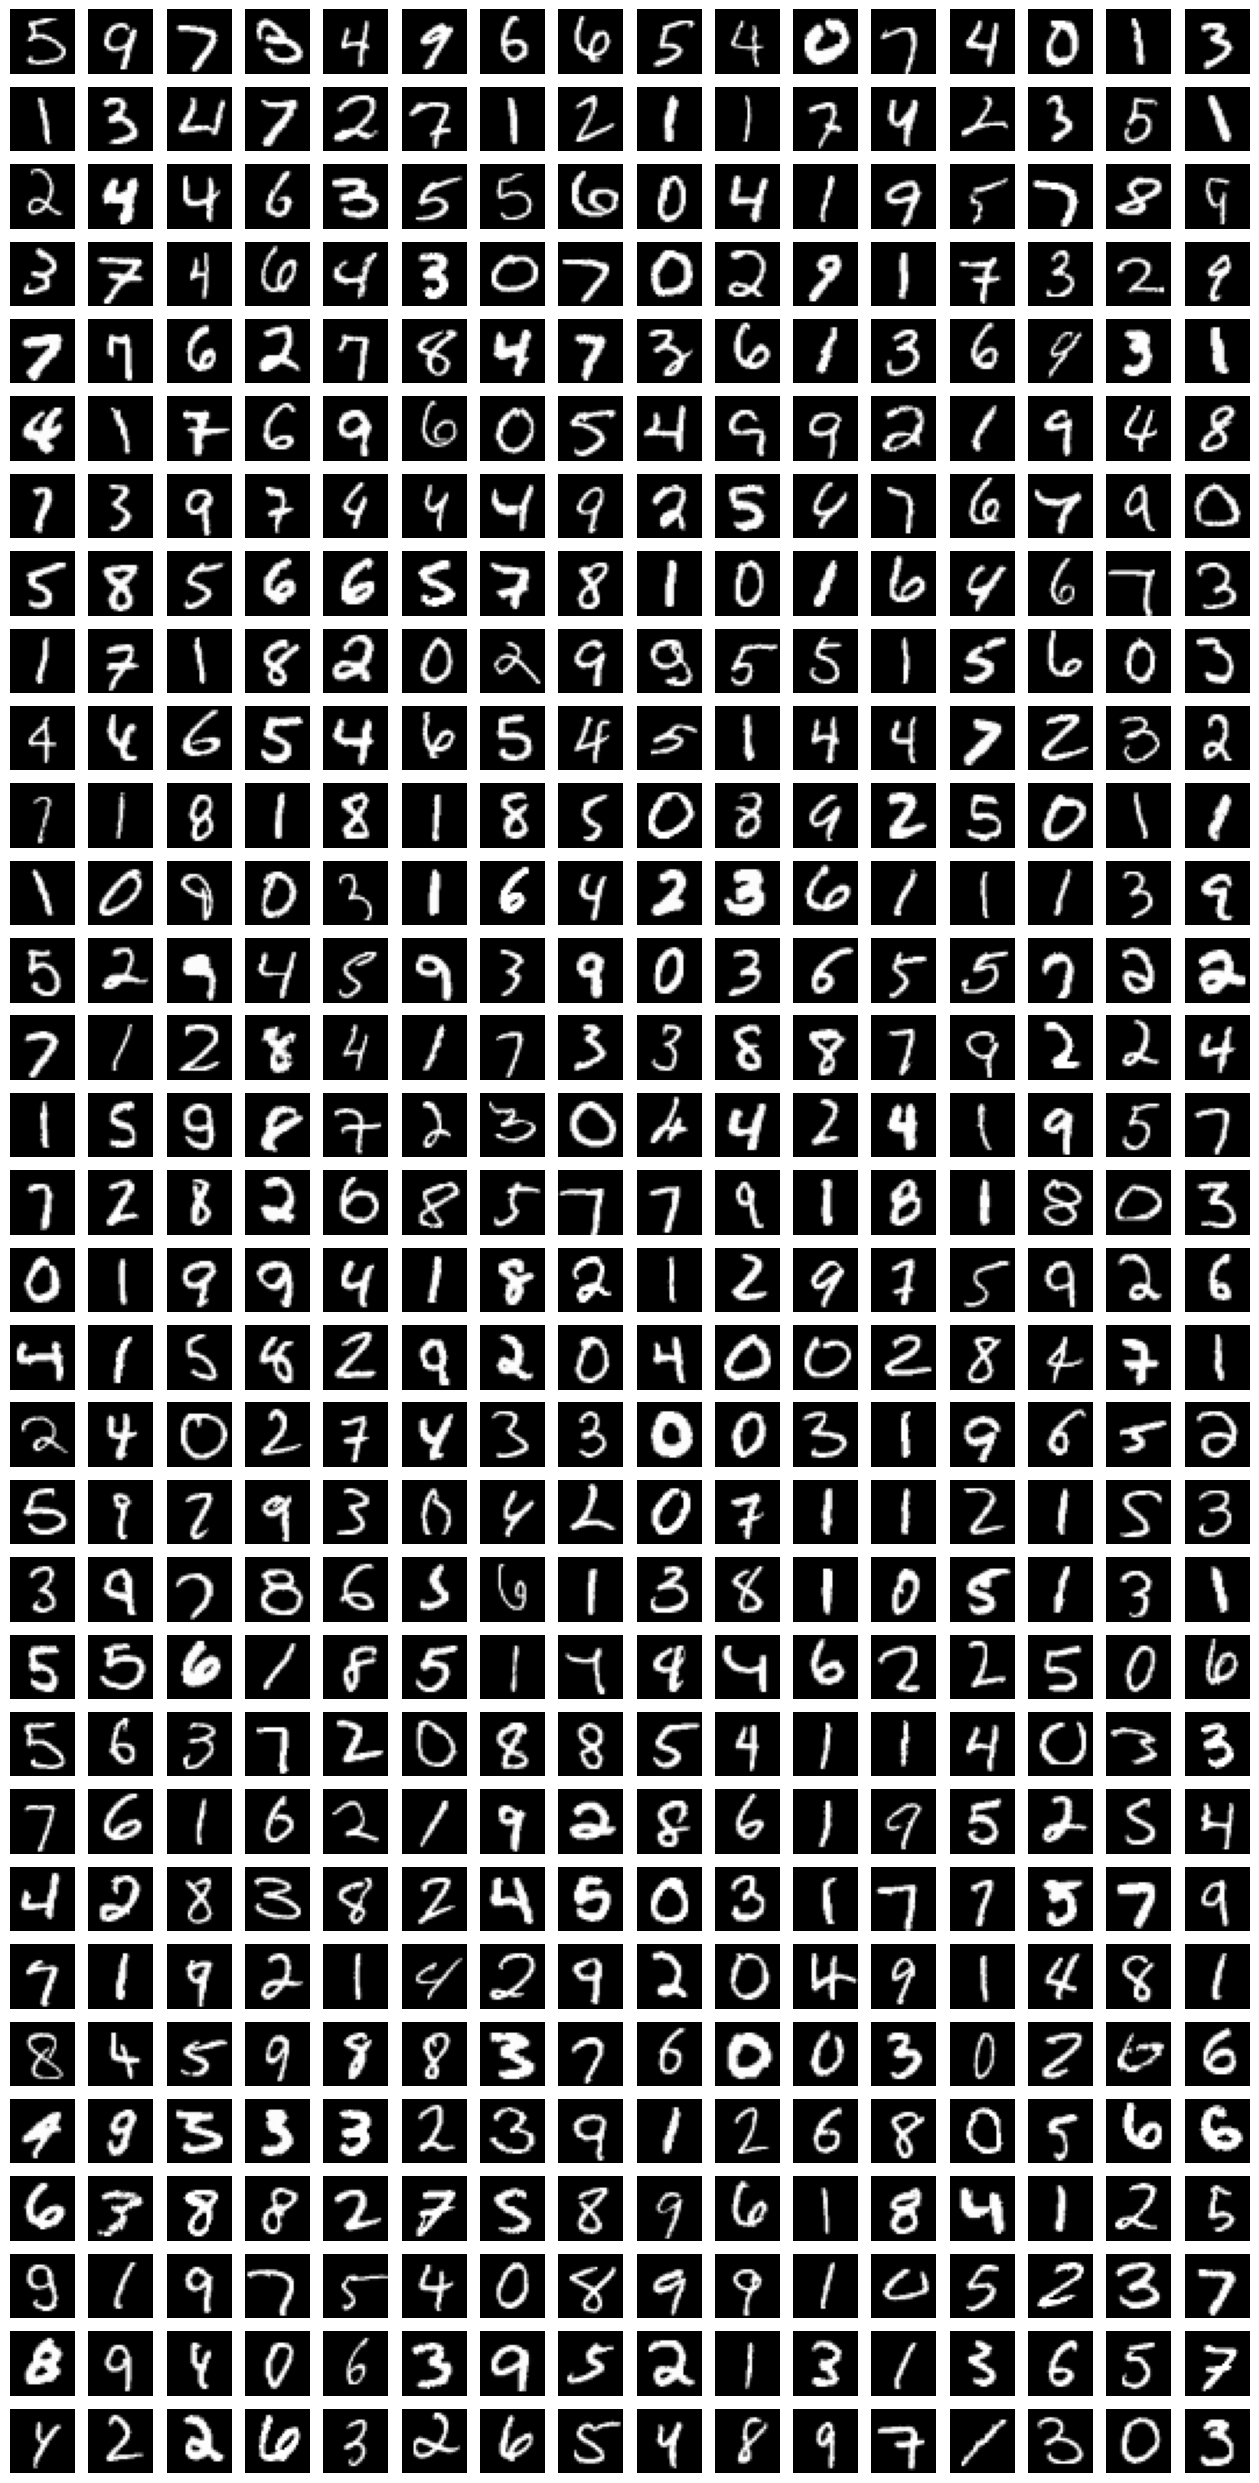

In [21]:
def showResultsInGrid(x, y_pred, y_gt, nb_to_display, nb_cols = 3, nb_rows = -1, show_label = False, coeff_row_with_label=1.3):
    if nb_rows <0:
        nb_rows = math.floor(nb_to_display/nb_cols)+1

    coeff_row = 1
    if show_label:
        coeff_row = 1.3
    plt.figure(figsize=(nb_cols*1, nb_rows*coeff_row))
    for i in np.arange(nb_to_display):
        ax = plt.subplot(nb_rows,nb_cols, i+1)
        
        # ind = idx+i
        ax.set_axis_off()
        if show_label:
            plt.title(f"{y_gt[i]}, l:{y_pred[i]}")
        plt.imshow(x[i], cmap="gray")
        # imshowAndLabel(x[i], y_test[i], labels_pred[i], figsize=(8,8))
        
nb_to_display = 512
nb_cols = 16
nb_rows = math.floor(nb_to_display/nb_cols)+1
start_idx = 15

nb_to_display = 512
nb_cols = 16
nb_rows = math.floor(nb_to_display/nb_cols)+1
start_idx = 15
show_label = False

# Get a part of images and label
x_test_filtered = x_test[start_idx:start_idx+nb_to_display]
y_gt = y_test[start_idx:start_idx+nb_to_display]

y_pred_one_hot = probability_model(x_test_filtered)
y_pred = np.argmax(y_pred_one_hot, axis=1) # gives the labels predicted

showResultsInGrid(x_test_filtered, y_pred, y_gt, nb_to_display, nb_cols=nb_cols, nb_rows = nb_rows, show_label=show_label)